# Superstore End-to-End Data Analysis

## Overview
This project demonstrates a complete end-to-end data analysis workflow using:

- SQL for business query analysis
- Python for data cleaning and customer analytics
- Power BI for dashboard visualization

## Business Objective
To analyze sales, profitability, and customer behavior in order to identify growth opportunities and business insights.

## SQL Analysis Layer

The dataset was assumed to be stored in a relational database.

SQL queries were used to:
- Calculate total sales and profit
- Analyze monthly sales trends
- Identify top-performing customers
- Evaluate category performance
- Detect repeat customers

The extracted business insights were then analyzed further in Python.

---

In [56]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Set visual style
sns.set_style("whitegrid")

## Data Loading

The dataset is loaded into Python using pandas for further analysis.

In [57]:
# load data
df = pd.read_csv("../data/Sample - Superstore.csv", encoding="latin1") # used encoding ="latin1" because UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa0
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


---
## Understanding the Dataset

Before analysis, it is important to inspect:
- shape of dataset
- column names
- data types
- missing values

In [58]:
# Shape of dataset
df.shape

(9994, 21)

In [59]:
# Column names
df.columns


Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [60]:
# Dataset information
df.info()

# Missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

---
## Data Cleaning

The dataset is cleaned to ensure accurate analysis.

Main tasks:
- Convert date columns
- Handle missing values
- Validate data types

In [61]:
# Convert safely
original_dates = df["Order Date"].copy()

# Convert Order Date to datetime
# errors="coerce" ensures invalid values become NaT instead of causing errors

df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")

# Identify invalid rows
invalid_rows = df[df["Order Date"].isnull()]

print("Invalid date rows:", len(invalid_rows))

# Optional: inspect them
invalid_rows.head()


Invalid date rows: 0


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


In [62]:

# Drop rows with missing Order Date (if any exist)
# .copy() is used to avoid SettingWithCopyWarning
df = df.dropna(subset=["Order Date"]).copy()


---
## Feature Engineering

To perform time-based analysis, we extract useful components from the `Order Date` column.

This includes:

• Year → to analyze yearly trends  
• Month → to analyze monthly sales patterns  

These features help in identifying seasonality and business trends.

In [63]:
# Extract year from Order Date
df["year"] = df["Order Date"].dt.year

# Extract month in YYYY-MM format
df["month"] = df["Order Date"].dt.to_period("M")

# dt.month gives 1,2,3... and df.to_period("M") gives 2021-01, 2022-01...

---
## Analysis: Monthly Sales Trend

This analysis examines how sales change over time and helps identify seasonal patterns and business growth trends.

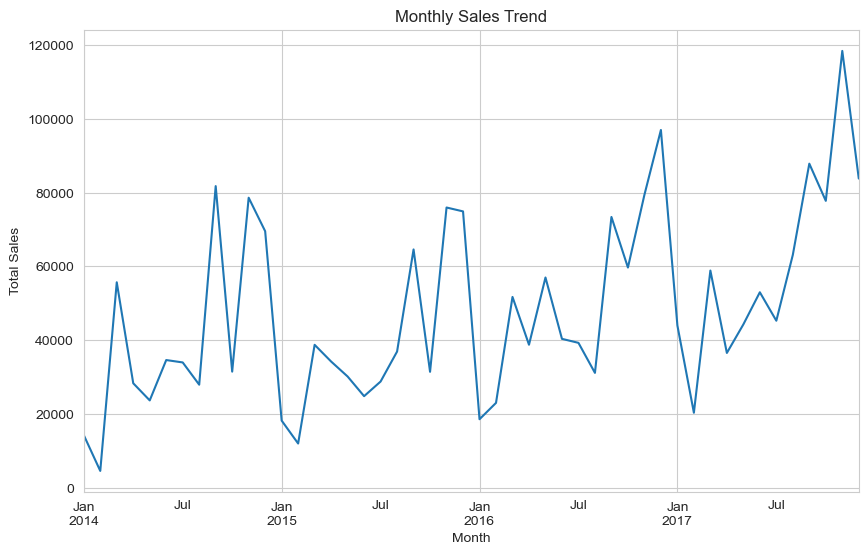

In [64]:
# Group data by month and calculate total sales
monthly_sales = df.groupby("month")["Sales"].sum()

# Plot the trend
plt.figure(figsize=(10,6))
monthly_sales.plot()

# Add labels and title for clarity
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.savefig("images/monthly_sales.png")
plt.show()

### Insight

Sales show noticeable fluctuations across months, indicating seasonality and varying customer demand patterns.

---
## Analysis 2(a): Category Performance

This analysis evaluates which product categories contribute the most to total sales.

Understanding category performance helps businesses focus on high-performing segments.

We group data by category to compare total sales and profit contribution across product segments.

In [65]:
df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,year,month
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,2016,2016-11
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,2016,2016-11


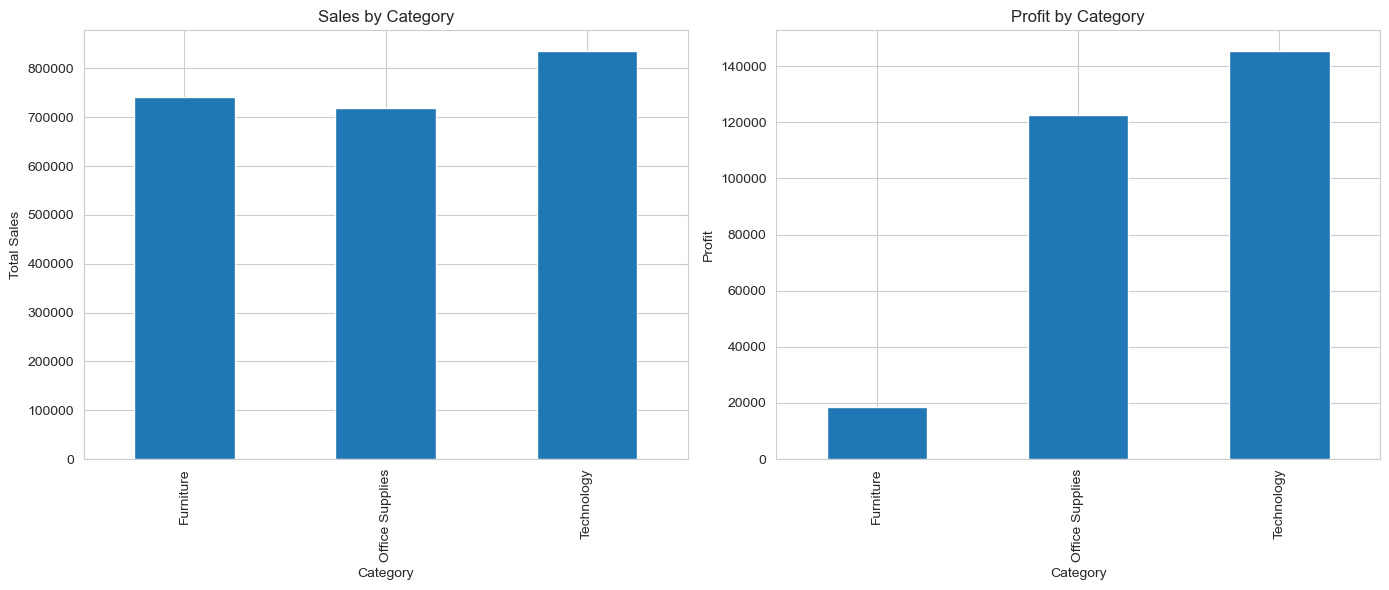

In [66]:
# Calculate total sales and total profit for each category, so that better insight can be made.


# Create subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Monthly Sales Trend
monthly_sales = df.groupby("Category")["Sales"].sum()
monthly_sales.plot(kind= "bar", ax=axes[0])
axes[0].set_title("Sales by Category")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Total Sales")


# Plot 2: Profit by Category
cat_profit = df.groupby("Category")["Profit"].sum()
cat_profit.plot(kind="bar", ax=axes[1])
axes[1].set_title("Profit by Category")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Profit")



# Adjust layout
plt.tight_layout()
plt.savefig("images/category_salesvsprofit.png")
plt.show()

### Insight

The analysis reveals a mismatch between sales and profitability across categories.

While Furniture contributes a substantial portion of total revenue, its profit margins are significantly lower, indicating potential inefficiencies such as high discounts, supply chain costs, or pricing issues.

Technology stands out as the most profitable category, delivering both high revenue and strong margins, making it a key driver of business performance.

Office Supplies maintains a balanced profile with consistent profitability despite moderate sales.

This suggests that focusing solely on revenue can be misleading, and profitability analysis is essential for strategic decision-making.

---
## Analysis 2(b): Sub-Category Performance
This analysis supplements the previous one to dive deep to understand which product is making profit and loss.

We further drill down into sub-categories to identify specific products driving profit or loss.

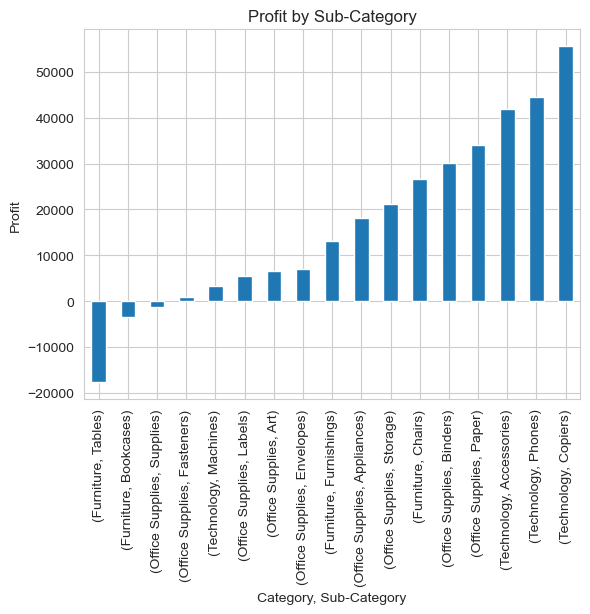

In [67]:
# Calculating the profits by the sub-categories

subcat_profit = df.groupby(["Category", "Sub-Category"])["Profit"].sum().sort_values()
subcat_profit.plot(kind="bar")
plt.title("Profit by Sub-Category")
plt.xlabel("Category, Sub-Category")
plt.ylabel("Profit")
plt.savefig("images/sub-categories.png")
plt.show()

### Insight

The analysis uncovers a critical mismatch between revenue contribution and profitability at the sub-category level.

Furniture sub-categories such as Tables and Bookcases are consistently loss-making, indicating structural issues like excessive discounting or high operational costs. Despite contributing to sales volume, these products negatively impact overall profitability.

In contrast, Technology sub-categories—especially Copiers and Phones—generate the highest profits, making them the most valuable segments for the business.

This suggests that profitability is concentrated in specific product groups rather than evenly distributed across categories. Strategic focus should be placed on optimizing or re-evaluating underperforming sub-categories while scaling high-margin segments to maximize business performance.

### Additional Insight

A small number of sub-categories contribute disproportionately to profits, while a few loss-making segments significantly reduce overall margins.

This indicates the importance of targeted decision-making rather than treating all products equally.

---
## Analysis 3: Profit by Region

This analysis evaluates how profitability varies across different regions.

Understanding regional performance helps identify strong markets and areas that require improvement.

We group data by region to evaluate geographic differences in profitability.

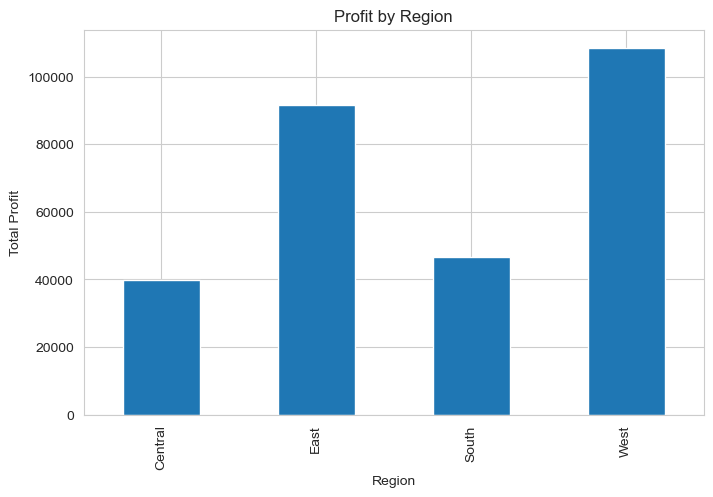

In [68]:
# Calculate total profit by region
region_profit = df.groupby("Region")["Profit"].sum()

# Plot
plt.figure(figsize=(8,5))
region_profit.plot(kind="bar")

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")

plt.show()

### Insight

Profitability varies across regions, indicating differences in market performance.

Some regions contribute significantly to overall profit, while others underperform.

This suggests that business strategies should be region-specific, focusing on strengthening weaker regions while maintaining performance in strong ones.


---
# 👥 Customer Segmentation using RFM Analysis

RFM analysis helps segment customers based on:

- Recency → How recently customer purchased
- Frequency → How often customer purchases
- Monetary → How much customer spends

This helps identify:
- loyal customers
- high-value customers
- at-risk customers

In [69]:
# Create a copy to avoid modifying original dataframe
rfm_df = df.copy()

# Ensure Order Date is datetime
rfm_df["Order Date"] = pd.to_datetime(rfm_df["Order Date"], errors="coerce")

# Drop missing dates safely
rfm_df = rfm_df.dropna(subset=["Order Date"]).copy()

In [70]:
rfm_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,year,month
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,2016-11
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,2016-11
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,2016-06
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,2015-10
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,2015-10


In [71]:
# Define reference date (latest date in dataset)
snapshot_date = rfm_df["Order Date"].max()

# Create RFM table
rfm = rfm_df.groupby("Customer Name").agg({
    "Order Date": lambda x: (snapshot_date - x.max()).days,  # Recency
    "Order ID": "count",  # Frequency
    "Sales": "sum"  # Monetary
}).reset_index()

# Rename columns
rfm.columns = ["Customer", "Recency", "Frequency", "Monetary"]

rfm.head()

,Customer,Recency,Frequency,Monetary
0,Aaron Bergman,415,6,886.156
1,Aaron Hawkins,12,11,1744.700
2,Aaron Smayling,88,10,3050.692
3,Adam Bellavance,54,18,7755.620
4,Adam Hart,34,20,3250.337


In [72]:
# Recency: lower is better → reverse scoring
rfm["R_score"] = pd.qcut(rfm["Recency"], 4, labels=[4,3,2,1])

# Frequency: higher is better
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1,2,3,4])
## rank(method="first") is used to handle duplicate values so qcut() can create unique quartile bins without errors.

# Monetary: higher is better
rfm["M_score"] = pd.qcut(rfm["Monetary"], 4, labels=[1,2,3,4])

In [73]:
rfm.head()

,Customer,Recency,Frequency,Monetary,R_score,F_score,M_score
0,Aaron Bergman,415,6,886.156,1,1,1
1,Aaron Hawkins,12,11,1744.700,4,2,2
2,Aaron Smayling,88,10,3050.692,2,2,3
3,Adam Bellavance,54,18,7755.620,3,4,4
4,Adam Hart,34,20,3250.337,3,4,3


In [74]:
# Combine scores into single RFM score
rfm["RFM_Score"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)
)

rfm.head()

,Customer,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,Aaron Bergman,415,6,886.156,1,1,1,111
1,Aaron Hawkins,12,11,1744.700,4,2,2,422
2,Aaron Smayling,88,10,3050.692,2,2,3,223
3,Adam Bellavance,54,18,7755.620,3,4,4,344
4,Adam Hart,34,20,3250.337,3,4,3,343


In [75]:
conditions = [
    (rfm["R_score"] == 4) & (rfm["F_score"] == 4) & (rfm["M_score"] == 4),

    (rfm["F_score"] >= 3) & (rfm["M_score"] >= 3),

    (rfm["R_score"] >= 3) & (rfm["F_score"] <= 2),

    (rfm["R_score"] == 1)
]

choices = [
    "Champions",
    "Loyal Customers",
    "Potential Loyalists",
    "At Risk"
]

rfm["Segment"] = np.select(conditions, choices, default="Others")
# np.select() assigns segment labels based on multiple vectorized conditions, similar to SQL CASE WHEN.

In [76]:
rfm.head()

,Customer,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
0,Aaron Bergman,415,6,886.156,1,1,1,111,Potential Loyalists
1,Aaron Hawkins,12,11,1744.700,4,2,2,422,Others
2,Aaron Smayling,88,10,3050.692,2,2,3,223,Potential Loyalists
3,Adam Bellavance,54,18,7755.620,3,4,4,344,Loyal Customers
4,Adam Hart,34,20,3250.337,3,4,3,343,Loyal Customers


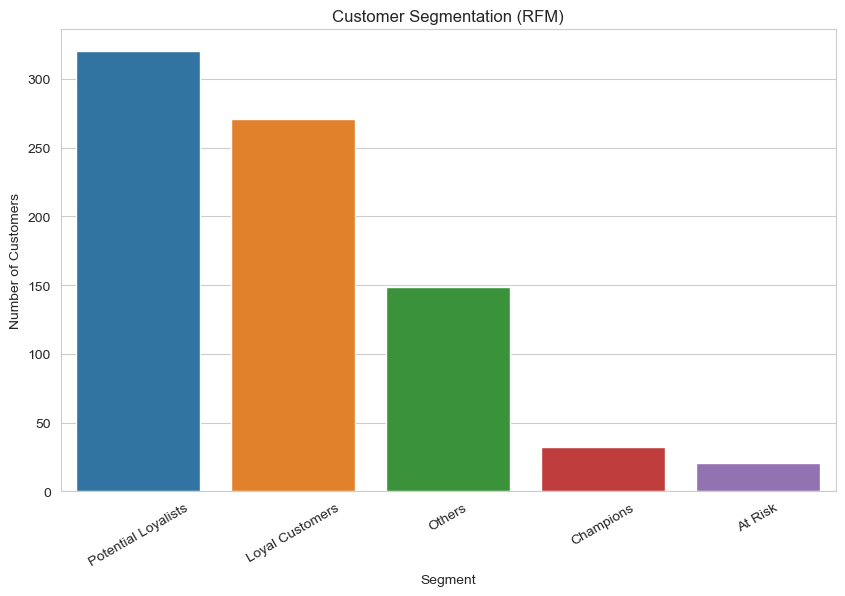

In [77]:
# Segment Distribution
plt.figure(figsize=(10,6))

sns.countplot(data=rfm, x="Segment", order=rfm["Segment"].value_counts().index)

plt.title("Customer Segmentation (RFM)")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)
plt.savefig("images/Segment Distribution.png")
plt.show()

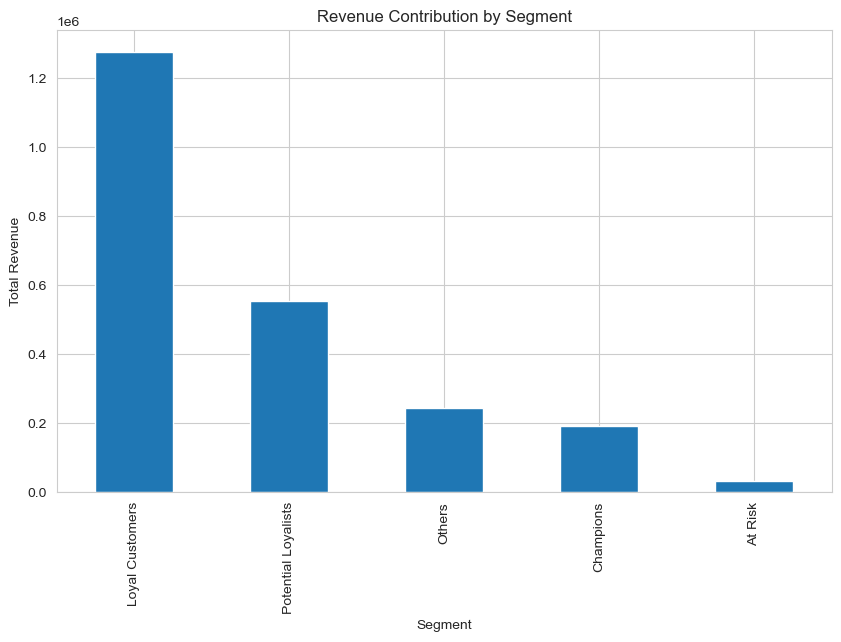

In [78]:
# Segment Revenue Contribution

segment_revenue = rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
segment_revenue.plot(kind="bar")

plt.title("Revenue Contribution by Segment")
plt.xlabel("Segment")
plt.ylabel("Total Revenue")

plt.show()

## RFM Insights

• A small group of customers (Champions and Loyal Customers) contributes a large portion of total revenue  

• High-value customers purchase frequently and spend significantly more, making them critical for business success  

• Potential Loyalists represent an opportunity for growth and can be converted into high-value customers through targeted strategies  

• At-risk customers have not purchased recently and may require re-engagement campaigns  

• The distribution shows that not all customers contribute equally, highlighting the importance of segmentation  

Overall, the business should focus on retaining high-value customers, nurturing mid-level customers, and re-engaging inactive ones to maximize revenue.

In [79]:
# Segment-wise metrics
segment_summary = rfm.groupby("Segment").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean",
    "Customer": "count"
}).rename(columns={"Customer": "Customer_Count"})

segment_summary

,Recency,Frequency,Monetary,Customer_Count
Segment,,,,
At Risk,317.809524,14.952381,1524.245152,21
Champions,16.250000,22.156250,5977.521556,32
Loyal Customers,107.660517,17.771218,4710.469940,271
Others,37.885906,11.577181,1629.187445,149
Potential Loyalists,232.496875,7.593750,1733.202310,320


### Segment-Level Insights

• Champions customers have the lowest recency and highest frequency and spending, making them the most valuable group  

• Loyal Customers consistently purchase and contribute significantly to revenue  

• Potential Loyalists show recent activity but lower frequency, indicating an opportunity for growth  

• At-risk customers have high recency (long time since last purchase) and require re-engagement  

• The customer base is unevenly distributed, with a small number of customers driving most of the value  

In [80]:
# Top 10 customers by revenue
top_customers = rfm.sort_values(by="Monetary", ascending=False).head(10)

top_customers

,Customer,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
686,Sean Miller,79,15,25043.050,2,3,4,234,Loyal Customers
730,Tamara Chand,399,12,19052.218,1,3,4,134,Loyal Customers
622,Raymond Buch,96,18,15117.339,2,4,4,244,Loyal Customers
757,Tom Ashbrook,69,10,14595.620,3,2,4,324,Potential Loyalists
6,Adrian Barton,41,20,14473.571,3,4,4,344,Loyal Customers
441,Ken Lonsdale,47,29,14175.229,3,4,4,344,Loyal Customers
671,Sanjit Chand,349,22,14142.334,1,4,4,144,Loyal Customers
334,Hunter Lopez,43,11,12873.298,3,2,4,324,Potential Loyalists
672,Sanjit Engle,9,19,12209.438,4,4,4,444,Champions
156,Christopher Conant,43,11,12129.072,3,2,4,324,Potential Loyalists


### Insight: Top Customers

A small number of customers contribute a disproportionately large share of total revenue.

These customers should be prioritized for retention strategies such as personalized offers, loyalty programs, and premium services.

---
## Data Export

The cleaned dataset is exported for visualization in Power BI.

In [81]:
df.to_csv("cleaned_data.csv", index=False)

---
#  Final Business Insights

- Technology category generates the highest sales and profit.
- Furniture category has lower profitability despite strong sales.
- Sales trends indicate seasonal fluctuations in customer demand.
- A small number of customers contribute heavily to total revenue.
- Profit margin suggests moderate business efficiency with room for optimization.

# Conclusion

This project demonstrates a complete business analysis workflow using SQL, Python, and Power BI to derive actionable insights from retail sales data.